In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

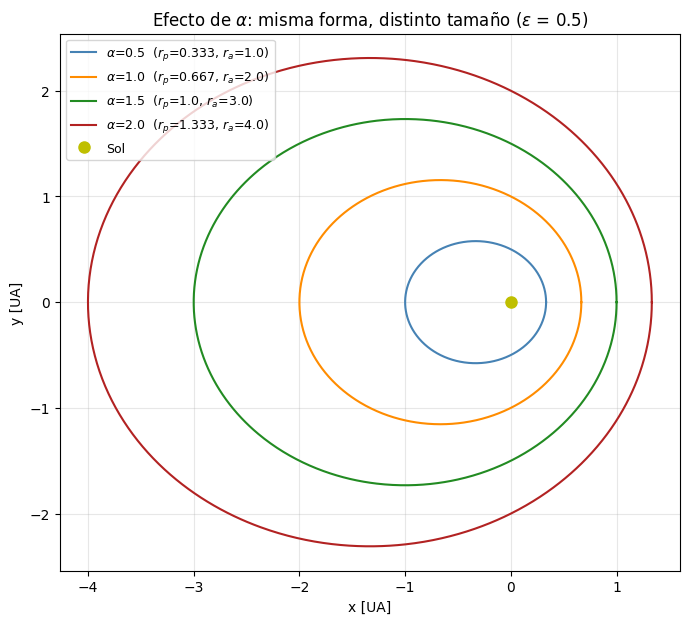

El perihelio es alpha/(1+eps) y el afelio es alpha/(1-eps).
Si alpha se duplica, ambos se duplican: la orbita crece proporcionalmente.


In [5]:
eps_fijo      = 0.5
alphas_prueba = [0.5, 1.0, 1.5, 2.0]
colores_alpha = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

ti_a = 0.0
tf_a = 2 * np.pi
lt_a = np.linspace(ti_a, tf_a, 1000)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect(1.0)
ax.set_title(r'Efecto de $\alpha$: misma forma, distinto tamaño ($\varepsilon$ = 0.5)')

for i in range(len(alphas_prueba)):
    a     = alphas_prueba[i]
    color = colores_alpha[i]

    estado_inicial = [(1 + eps_fijo) / a, 0.0]
    sol = solve_ivp(derivadas, [ti_a, tf_a], estado_inicial,
                    t_eval=lt_a, args=(a, 0.0),
                    rtol=1e-9, atol=1e-11)

    x, y = a_cartesiano(sol.t, sol.y[0])

    perihelio = round(a / (1 + eps_fijo), 3)
    afelio    = round(a / (1 - eps_fijo), 3)
    ax.plot(x, y, color=color, lw=1.5,
            label=rf'$\alpha$={a}  ($r_p$={perihelio}, $r_a$={afelio})')

ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'graficos\figura_3_efecto_alpha.png', dpi=120, bbox_inches='tight')
plt.show()

print('El perihelio es alpha/(1+eps) y el afelio es alpha/(1-eps).')
print('Si alpha se duplica, ambos se duplican: la orbita crece proporcionalmente.')